In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import time

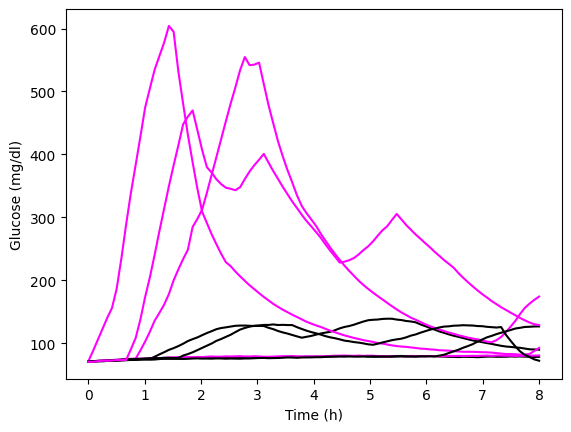

In [6]:
def subsample(v, k0, k1):
    zeros_idx = np.where(v == 0)[0]
    ones_idx = np.where(v == 1)[0]
    zeros_idx = np.random.choice(zeros_idx, k0, replace=True)
    ones_idx = np.random.choice(ones_idx, k1, replace=True)
    selected = np.concatenate([
        zeros_idx,ones_idx
    ])
    
    return zeros_idx,ones_idx,selected  # indices into v


# Synthetic data simulation
# Food comes in as Poisson events
# Food passes through a random "glucotype" convolution
# Pathology = delay between event and peak insulin response

sampPerHour = 12
maxBolusHours = 2
mealsPerDay = 3 # average
sampHours = 8
T = sampHours*sampPerHour
halflifeHours = 1
k = np.log(2)/(halflifeHours*sampPerHour)
maxDelay = int(sampPerHour)
doFftFeats = True
sampleSetSize = 500
trainSetSize = 400
allX = np.zeros((8,sampleSetSize,T*2))
dx = np.zeros((8,sampleSetSize))
minMeals = 1
minTypes = 1
maxTypes = 20
maxMeals = 20
gtypeCount = maxTypes*1
mealLibCount = maxMeals*1
gtypeLibrary = np.zeros((gtypeCount,maxBolusHours*sampPerHour))
mealLibrary = np.zeros((mealLibCount,maxBolusHours*sampPerHour))
for ii in range(mealLibCount):
    bolusRightInd = (maxBolusHours*sampPerHour)
    # bolusRightInd = np.random.randint(maxBolusHours*sampPerHour)
    mealLibrary[ii,:bolusRightInd] = np.random.rand(bolusRightInd)*50
for ii in range(gtypeCount):
    bolusRightInd = (maxBolusHours*sampPerHour)
    # bolusRightInd = np.random.randint(maxBolusHours*sampPerHour)
    convWith = np.random.rand(bolusRightInd)
    convWith = convWith/np.sum(convWith) # normalize to one
    gtypeLibrary[ii,:bolusRightInd] = convWith

pInd = 0
for inclIns in [0,1]:
    for mealLibCount in [minMeals,maxMeals]:
        for gtypeCount in [minTypes,maxTypes]:
            for ii in range(sampleSetSize):
                x = np.zeros(T)
                w = np.zeros(T)
                u = np.zeros(T)
                insulin = np.zeros(T)
                uFwd = np.zeros(T)
                ctrlFwd = int(np.random.randint(0,2))*maxDelay
                dx[pInd,ii] = ctrlFwd
                for tt in range(T):
                    if np.random.rand()<(mealsPerDay/(T)):
                        bolusRightInd = np.min([tt+maxBolusHours*sampPerHour,T])
                        w[tt:bolusRightInd] += np.convolve(mealLibrary[np.random.randint(mealLibCount),:(bolusRightInd-tt)],gtypeLibrary[np.random.randint(gtypeCount),:(bolusRightInd-tt)],'same')
                        uFwd[(tt+ctrlFwd):bolusRightInd] += .8*w[(tt+ctrlFwd):bolusRightInd]
                    if tt-1 > 0:
                        u[tt]+= k*x[tt-1]
                    wtruenoise = np.random.rand()
                    leftInd = np.max([tt-1,0])    
                    x[tt] = np.max([x[leftInd] + w[tt] - u[tt]-uFwd[tt]+wtruenoise,0])
                    insulin[tt] = (u[tt]+uFwd[tt])/(x[tt]+100)
                if ii == 0:
                    if dx[pInd,ii]>0:
                        plt.plot(np.linspace(0,sampHours,T),x+70,'magenta')
                    else:
                        plt.plot(np.linspace(0,sampHours,T),x+70,'k')
                    plt.xlabel('Time (h)')
                    plt.ylabel('Glucose (mg/dl)')
                    
                if doFftFeats:
                    allX[pInd,ii,:T] = np.real(np.fft.fft(x))
                    if inclIns:
                        allX[pInd,ii,T:] = np.real(np.fft.fft(insulin))
                else:
                    allX[pInd,ii,:T] = x
                    if inclIns:
                        allX[pInd,ii,T:] = insulin
            pInd+=1
                        

In [7]:
xax = [10,20,30,40,50,75,100,150,200]
pInd = 0
numReps = 100
for inclIns in [0,1]:
    for mealLibCount in [minMeals,maxMeals]:
        for gtypeCount in [minTypes,maxMeals]:
            tic = time.time()
            dxp = np.clip(dx[pInd,:],0,1)
            
            dxp_train = dxp[:trainSetSize]
            dxp_test = dxp[trainSetSize:]
            allscores = []
            alluncertainty = []

            for ii in xax:
                subsel = []
                for jj in range(numReps):
                    chooseThese0,chooseThese1,_ = subsample(dxp_train,int(ii*trainSetSize/sampleSetSize),int(ii*trainSetSize/sampleSetSize))
                    chooseThese = np.concatenate((chooseThese0[:int(ii/2)],chooseThese1[:int(ii/2)]))                     
                    dr = LDA(shrinkage='auto', solver='eigen')
                    scaler = StandardScaler()
                    if inclIns:
                        scaler = StandardScaler()
                        X_train_scaled = scaler.fit_transform(allX[pInd,chooseThese[:ii],::2])
                        X_test_scaled = scaler.transform(allX[pInd,trainSetSize:,::2])  # use transform only, not fit_transform
                    else:
                        X_train_scaled = scaler.fit_transform(allX[pInd,chooseThese[:ii],:T:2])
                        X_test_scaled = scaler.transform(allX[pInd,trainSetSize:,:T:2])  # use transform only, not fit_transform
                    m=dr.fit(X_train_scaled,dxp_train[chooseThese[:ii]])
                    scores = m.score(X_test_scaled,dxp_test)
                    subsel.append(np.array(1.0-scores))
                allscores.append(np.mean(subsel))
                alluncertainty.append(np.std(subsel)/np.sqrt(numReps))
            s = 'Insulin Measured = ' + str(inclIns) + ', Meals = ' + str(mealLibCount)+ ', Glucotypes = ' + str(gtypeCount)
            print(s)
            print(np.max(allscores))
            toc = time.time()
            print(toc-tic,'Seconds Elapsed')
            if pInd == 0:
                allcurves = np.zeros((8,len(allscores)))
                allclouds = np.zeros((8,len(allscores)))
            allcurves[pInd,:] = np.array(allscores)
            allclouds[pInd,:] = np.array(alluncertainty)

            pInd +=1

Insulin Measured = 0, Meals = 1, Glucotypes = 1
0.2321
21.327493906021118 Seconds Elapsed
Insulin Measured = 0, Meals = 1, Glucotypes = 20
0.2742
18.407744646072388 Seconds Elapsed
Insulin Measured = 0, Meals = 20, Glucotypes = 1
0.24419999999999997
22.1683931350708 Seconds Elapsed
Insulin Measured = 0, Meals = 20, Glucotypes = 20
0.2752
22.10699486732483 Seconds Elapsed
Insulin Measured = 1, Meals = 1, Glucotypes = 1
0.2754
341.6175470352173 Seconds Elapsed
Insulin Measured = 1, Meals = 1, Glucotypes = 20
0.262
341.9757471084595 Seconds Elapsed
Insulin Measured = 1, Meals = 20, Glucotypes = 1
0.2694
345.9534969329834 Seconds Elapsed
Insulin Measured = 1, Meals = 20, Glucotypes = 20
0.30039999999999994
333.81171894073486 Seconds Elapsed


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


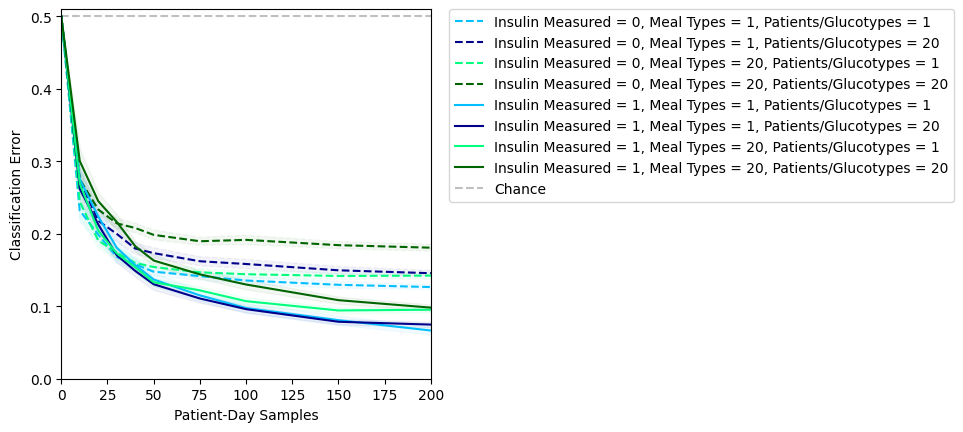

In [8]:

plt.figure()

allcol = ['deepskyblue','darkblue','springgreen','darkgreen']
for pInd,inclIns,mealLibCount,gtypeCount in zip(range(8),[0,0,0,0,1,1,1,1],[minMeals,minMeals,maxMeals,maxMeals,minMeals,minMeals,maxMeals,maxMeals],[minTypes,maxTypes,minTypes,maxTypes,minTypes,maxTypes,minTypes,maxTypes]):
    if mealLibCount == minMeals and gtypeCount == minTypes:
        colInd = 0
    elif mealLibCount == maxMeals and gtypeCount == minTypes:
        colInd = 2
    elif mealLibCount == minMeals and gtypeCount == maxTypes:
        colInd = 1
    elif mealLibCount == maxMeals and gtypeCount == maxTypes:
        colInd = 3
    if inclIns:
        ls = '-'
    else:
        ls = '--' 
    
    s = 'Insulin Measured = ' + str(inclIns) + ', Meal Types = ' + str(mealLibCount)+ ', Patients/Glucotypes = ' + str(gtypeCount)
    plt.plot(np.concatenate(([0],xax)),np.concatenate(([0.5],allcurves[pInd,:])),color=allcol[colInd],linestyle=ls,label=s)
    plt.fill_between(np.concatenate(([0],xax)), 
                 np.concatenate(([0.5],allcurves[pInd,:])) - np.concatenate(([0],2*allclouds[pInd,:])), 
                 np.concatenate(([0.5],allcurves[pInd,:])) + np.concatenate(([0],2*allclouds[pInd,:])), 
                 alpha=0.05, 
                     
                 color=allcol[colInd], 
                 linestyle=ls,
                 label='_')
 
plt.plot(np.concatenate(([0],xax)),np.ones(int(np.shape(xax)[0])+1)*.5,'k--',alpha = .25, label='Chance')
plt.xlim((0,xax[-1]))

plt.ylim((0,0.51))

plt.xlabel('Patient-Day Samples')
plt.ylabel('Classification Error')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.gca().set_box_aspect(1)


plt.savefig('MeasureInsulin-10.eps')